<a href="https://colab.research.google.com/github/eshghinezhad/DeepLearning/blob/master/Weather%20Forecasting%20with%20Sequence%20Models/scenario1_rnn_weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weather Forecasting with Sequence Models — Scenario 1

**Scenario 1: Single-step (14 → 1)**
Feature: `BASEL_temp_mean` · Slide a 14-day window, predict the next 1 day.

For this scenario we build and compare 4 sequence models:
- **S1-a** Simple RNN
- **S1-b** Deeper RNN
- **S1-c** LSTM
- **S1-d** GRU

Dataset: [Kaggle — Weather Prediction Dataset](https://www.kaggle.com/datasets/thedevastator/weather-prediction/data) (`weather_prediction_dataset.csv`).

> **Colab note:** upload `weather_prediction_dataset.csv` to the Colab session (or mount Drive) so it sits in the working directory, then run all cells top to bottom.


## 0. Setup

In [28]:
# Core imports
import sys, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [29]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device: use a GPU/accelerator if available (Colab: Runtime > Change runtime type > GPU)
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")


Using device: cpu


## 1. Load & Explore the Dataset

---



Simple local read — place `weather_prediction_dataset.csv` in the same directory as this notebook
(or adjust `DATA_PATH` below).

In [30]:
DATA_PATH = "weather_prediction_dataset.csv"  # <-- adjust if needed

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(3654, 165)


,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-9.3,0.7,1.6,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,0.5,2.0,2.0,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-1.0,2.8,3.4,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,2.5,4.6,4.9,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-1.8,2.9,3.6,0.95,1.0209,0.39,0.04,8.0,6.4,9.5


In [31]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Columns: 165 entries, DATE to TOURS_temp_max
dtypes: float64(150), int64(15)
memory usage: 4.6 MB


In [32]:
# The DATE column is typically an integer like 20000101 (YYYYMMDD) -> parse to real dates
# and use it as a proper chronological index (important: never shuffle a time series!)
df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d")
df = df.sort_values("DATE").set_index("DATE")
df.head()


,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,...,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
DATE,,,,,,,,,,,,,,,,,,,,,
2000-01-01,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,3.9,...,-9.3,0.7,1.6,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
2000-01-02,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,4.8,...,0.5,2.0,2.0,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2000-01-03,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,4.8,...,-1.0,2.8,3.4,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
2000-01-04,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,7.5,...,2.5,4.6,4.9,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
2000-01-05,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,8.6,...,-1.8,2.9,3.6,0.95,1.0209,0.39,0.04,8.0,6.4,9.5


In [33]:
# Sanity checks before modeling: missing values, duplicate dates, and the columns
# this assignment actually needs across all 4 scenarios
needed_cols = [
    "BASEL_temp_mean", "BASEL_humidity",
    "MAASTRICHT_temp_mean", "DUSSELDORF_temp_mean", "MUENCHEN_temp_mean", "DE_BILT_temp_mean",
    "MAASTRICHT_humidity", "DUSSELDORF_humidity", "MUENCHEN_humidity", "DE_BILT_humidity",
]
missing = [c for c in needed_cols if c not in df.columns]
print("Missing expected columns:", missing)
print("\nNaN counts (only needed columns):")
print(df[needed_cols].isna().sum())
print("\nDuplicate dates:", df.index.duplicated().sum())


Missing expected columns: []

NaN counts (only needed columns):
BASEL_temp_mean         0
BASEL_humidity          0
MAASTRICHT_temp_mean    0
DUSSELDORF_temp_mean    0
MUENCHEN_temp_mean      0
DE_BILT_temp_mean       0
MAASTRICHT_humidity     0
DUSSELDORF_humidity     0
MUENCHEN_humidity       0
DE_BILT_humidity        0
dtype: int64

Duplicate dates: 0


In [34]:
# Explore BASEL_temp_mean specifically (this scenario's feature)
df["BASEL_temp_mean"].describe()


,BASEL_temp_mean
count,3654.000000
mean,11.022797
std,7.414754
min,-9.300000
25%,5.300000
50%,11.400000
75%,16.900000
max,29.000000


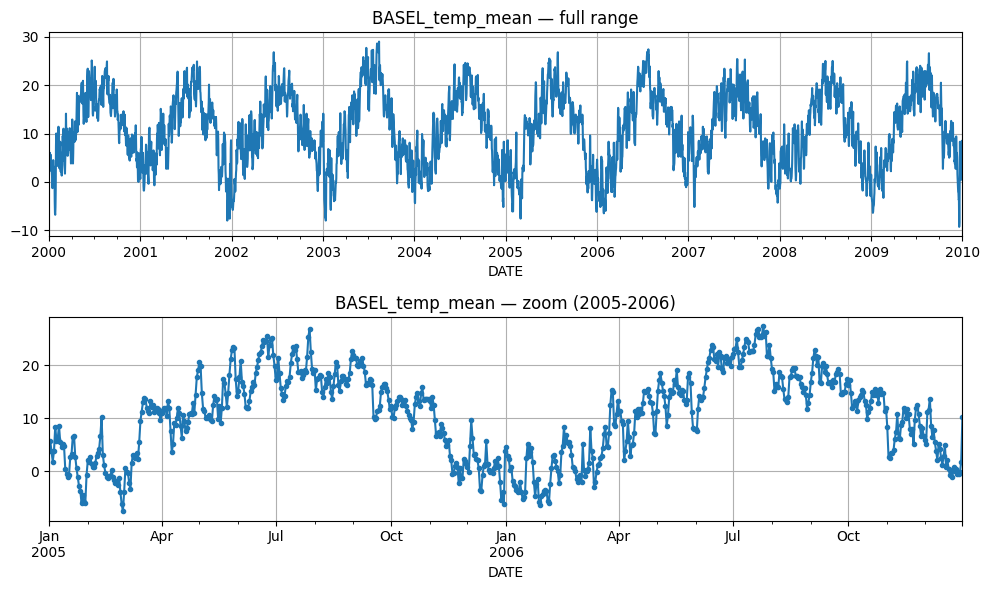

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
df["BASEL_temp_mean"].plot(ax=axes[0], grid=True, title="BASEL_temp_mean — full range")
df["BASEL_temp_mean"].loc["2005-01":"2006-12"].plot(ax=axes[1], grid=True, marker=".",
                                                     title="BASEL_temp_mean — zoom (2005-2006)")
plt.tight_layout()
plt.show()


## 2. Prepare the Dataset for Scenario 1

**Design decisions (consistent across all 4 scenarios in this assignment):**
- **Chronological split, no shuffling** for train/test (70/30) — a time series must not be split randomly,
  or the model would "see the future" during training.
- A **holdout validation set** is carved out of the training portion (chronologically, right before the
  test period) rather than k-fold, since k-fold would again mix future/past across folds.
- **Standardization** (zero mean, unit variance) computed **only on the training set**, then applied to
  validation/test — this avoids leaking test statistics into training.
- **Many-to-one framing**: a 14-day window is consumed by the RNN, and only the hidden state after the
  final step is used to predict the next single day (`output[:, -1]` pattern from the lab, not the
  seq2seq pattern).


In [36]:
# --- 2.1 Chronological 70/30 split, with a validation holdout carved from the 70% ---
n = len(df)
test_start = int(n * 0.70)
train_val_df = df.iloc[:test_start]
test_df = df.iloc[test_start:]

# carve validation out of the train_val portion (e.g. last 15% of it), still chronological
val_start = int(len(train_val_df) * 0.85)
train_df = train_val_df.iloc[:val_start]
val_df = train_val_df.iloc[val_start:]

print(f"train: {train_df.index.min().date()} -> {train_df.index.max().date()}  ({len(train_df)} rows)")
print(f"val:   {val_df.index.min().date()} -> {val_df.index.max().date()}  ({len(val_df)} rows)")
print(f"test:  {test_df.index.min().date()} -> {test_df.index.max().date()}  ({len(test_df)} rows)")


train: 2000-01-01 -> 2005-12-12  (2173 rows)
val:   2005-12-13 -> 2006-12-31  (384 rows)
test:  2007-01-01 -> 2010-01-01  (1097 rows)


In [37]:
# --- 2.2 Standardize using TRAIN statistics only ---
feature_cols_s1 = ["BASEL_temp_mean"]

train_mean = train_df[feature_cols_s1].mean()
train_std = train_df[feature_cols_s1].std()

def standardize(frame):
    return (frame[feature_cols_s1] - train_mean) / train_std

train_s1 = torch.FloatTensor(standardize(train_df).values)
val_s1   = torch.FloatTensor(standardize(val_df).values)
test_s1  = torch.FloatTensor(standardize(test_df).values)

train_s1.shape, val_s1.shape, test_s1.shape


(torch.Size([2173, 1]), torch.Size([384, 1]), torch.Size([1097, 1]))

In [38]:
# --- 2.3 Base sliding-window Dataset (generalizes the lab's TimeSeriesDataset with a `horizon` arg) ---
class TimeSeriesDataset(Dataset):
    """
    series: FloatTensor of shape (T, num_columns), already standardized
    window_length: number of past steps the model sees
    horizon: number of future steps to predict (>=1)
    """
    def __init__(self, series, window_length, horizon):
        self.series = series
        self.window_length = window_length
        self.horizon = horizon

    def __len__(self):
        return len(self.series) - self.window_length - self.horizon + 1

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length            # 1st index after the window
        window = self.series[idx: end]             # (window_length, num_columns)
        target = self.series[end: end + self.horizon]  # (horizon, num_columns)
        return window, target


In [39]:
# --- 2.4 Scenario-1-specific subclass ---
# Univariate input, single-step target -> flatten target to a flat vector, matching the lab's convention
# (e.g. lab's plain TimeSeriesDataset target shape (1,), MultaskTimeSeriesDataset used target[:2] etc.)
class Scenario1Dataset(TimeSeriesDataset):
    def __getitem__(self, idx):
        window, target = super().__getitem__(idx)
        target = target.reshape(-1)   # (horizon=1, 1 col) -> flat vector shape (1,)
        return window, target


In [40]:
WINDOW_LENGTH = 14
HORIZON = 1

s1_train_set = Scenario1Dataset(train_s1, WINDOW_LENGTH, HORIZON)
s1_val_set   = Scenario1Dataset(val_s1,   WINDOW_LENGTH, HORIZON)
s1_test_set  = Scenario1Dataset(test_s1,  WINDOW_LENGTH, HORIZON)

BATCH_SIZE = 32
s1_train_loader = DataLoader(s1_train_set, batch_size=BATCH_SIZE, shuffle=True)
s1_val_loader   = DataLoader(s1_val_set,   batch_size=BATCH_SIZE)
s1_test_loader  = DataLoader(s1_test_set,  batch_size=BATCH_SIZE)

# Sanity check the shapes before building any model
xb, yb = next(iter(s1_train_loader))
print("window batch shape:", xb.shape)   # expect (batch, 14, 1)
print("target batch shape:", yb.shape)   # expect (batch, 1)


window batch shape: torch.Size([32, 14, 1])
target batch shape: torch.Size([32, 1])


## 3. Build & Train the Models (S1-a to S1-d)

---



---



---



All four models share:
- the same **input framing** (window batch shape `(batch, 14, 1)`),
- the same **many-to-one forward pattern**: run the recurrent layer over the window, take only the
  **last** time step's output, pass it through a final `Linear` to produce the forecast,
- the same **training setup** (Adam, MSE loss, a fixed epoch budget), so that comparisons between
  models reflect the architecture, not incidental training differences.

A shared `train_and_evaluate` utility below records **training time** and validation/test **MAE**
for every model, so Section 4 can build a fair comparison table.

In [41]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def evaluate_mae(model, loader):
    model.eval()
    total_abs_err, n = 0.0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        total_abs_err += (y_pred - y).abs().sum().item()
        n += y.numel()
    return total_abs_err / n


def train_and_evaluate(model, train_loader, val_loader, test_loader,
                        lr=1e-3, n_epochs=20, model_name="model"):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    start = time.time()
    for epoch in range(n_epochs):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            loss.backward()
            # gradient clipping: standard/appropriate practice for RNNs, guards against exploding grads
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        val_mae = evaluate_mae(model, val_loader)
        print(f"[{model_name}] epoch {epoch+1:>2}/{n_epochs} — val MAE (standardized units): {val_mae:.4f}")

    training_time = time.time() - start
    test_mae = evaluate_mae(model, test_loader)

    return {
        "model": model_name,
        "params": count_params(model),
        "training_time_sec": round(training_time, 2),
        "val_mae": round(val_mae, 4),
        "test_mae": round(test_mae, 4),
    }


results_s1 = []  # collect one dict per model here


### S1-a — Simple RNN

In [42]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])   # many-to-one: only last step's hidden state


torch.manual_seed(SEED)
s1a_model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1)
res = train_and_evaluate(s1a_model, s1_train_loader, s1_val_loader, s1_test_loader, lr=0.01, n_epochs=20, model_name="S1-a SimpleRNN")
results_s1.append(res)
res


[S1-a SimpleRNN] epoch  1/20 — val MAE (standardized units): 0.2323
[S1-a SimpleRNN] epoch  2/20 — val MAE (standardized units): 0.2440
[S1-a SimpleRNN] epoch  3/20 — val MAE (standardized units): 0.2295
[S1-a SimpleRNN] epoch  4/20 — val MAE (standardized units): 0.2259
[S1-a SimpleRNN] epoch  5/20 — val MAE (standardized units): 0.2265
[S1-a SimpleRNN] epoch  6/20 — val MAE (standardized units): 0.2217
[S1-a SimpleRNN] epoch  7/20 — val MAE (standardized units): 0.2273
[S1-a SimpleRNN] epoch  8/20 — val MAE (standardized units): 0.2378
[S1-a SimpleRNN] epoch  9/20 — val MAE (standardized units): 0.2256
[S1-a SimpleRNN] epoch 10/20 — val MAE (standardized units): 0.2309
[S1-a SimpleRNN] epoch 11/20 — val MAE (standardized units): 0.2262
[S1-a SimpleRNN] epoch 12/20 — val MAE (standardized units): 0.2612
[S1-a SimpleRNN] epoch 13/20 — val MAE (standardized units): 0.2283
[S1-a SimpleRNN] epoch 14/20 — val MAE (standardized units): 0.2336
[S1-a SimpleRNN] epoch 15/20 — val MAE (standard

{'model': 'S1-a SimpleRNN',
 'params': 1153,
 'training_time_sec': 10.22,
 'val_mae': 0.2268,
 'test_mae': 0.2193}

S1-b — Deeper RNN

In [43]:
class DeepRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=3, dropout=0.0):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True, dropout=dropout)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])


torch.manual_seed(SEED)
# dropout between stacked recurrent layers is a standard regularization practice for deeper RNNs
s1b_model = DeepRnnModel(input_size=1, hidden_size=32, output_size=1, num_layers=3, dropout=0.1)
res = train_and_evaluate(s1b_model, s1_train_loader, s1_val_loader, s1_test_loader,
                          lr=0.01, n_epochs=20, model_name="S1-b DeepRNN")
results_s1.append(res)
res


[S1-b DeepRNN] epoch  1/20 — val MAE (standardized units): 0.2754
[S1-b DeepRNN] epoch  2/20 — val MAE (standardized units): 0.2616
[S1-b DeepRNN] epoch  3/20 — val MAE (standardized units): 0.2963
[S1-b DeepRNN] epoch  4/20 — val MAE (standardized units): 0.2792
[S1-b DeepRNN] epoch  5/20 — val MAE (standardized units): 0.2620
[S1-b DeepRNN] epoch  6/20 — val MAE (standardized units): 0.2685
[S1-b DeepRNN] epoch  7/20 — val MAE (standardized units): 0.2750
[S1-b DeepRNN] epoch  8/20 — val MAE (standardized units): 0.2629
[S1-b DeepRNN] epoch  9/20 — val MAE (standardized units): 0.2577
[S1-b DeepRNN] epoch 10/20 — val MAE (standardized units): 0.2453
[S1-b DeepRNN] epoch 11/20 — val MAE (standardized units): 0.2546
[S1-b DeepRNN] epoch 12/20 — val MAE (standardized units): 0.2565
[S1-b DeepRNN] epoch 13/20 — val MAE (standardized units): 0.3114
[S1-b DeepRNN] epoch 14/20 — val MAE (standardized units): 0.2610
[S1-b DeepRNN] epoch 15/20 — val MAE (standardized units): 0.2795
[S1-b Deep

{'model': 'S1-b DeepRNN',
 'params': 5377,
 'training_time_sec': 10.54,
 'val_mae': 0.3155,
 'test_mae': 0.2993}

### S1-c — LSTM

In [44]:
class LstmModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])


torch.manual_seed(SEED)
s1c_model = LstmModel(input_size=1, hidden_size=32, output_size=1)
res = train_and_evaluate(s1c_model, s1_train_loader, s1_val_loader, s1_test_loader,
                          lr=0.01, n_epochs=20, model_name="S1-c LSTM")
results_s1.append(res)
res


[S1-c LSTM] epoch  1/20 — val MAE (standardized units): 0.2499
[S1-c LSTM] epoch  2/20 — val MAE (standardized units): 0.2234
[S1-c LSTM] epoch  3/20 — val MAE (standardized units): 0.2221
[S1-c LSTM] epoch  4/20 — val MAE (standardized units): 0.2325
[S1-c LSTM] epoch  5/20 — val MAE (standardized units): 0.2191
[S1-c LSTM] epoch  6/20 — val MAE (standardized units): 0.2327
[S1-c LSTM] epoch  7/20 — val MAE (standardized units): 0.2453
[S1-c LSTM] epoch  8/20 — val MAE (standardized units): 0.2202
[S1-c LSTM] epoch  9/20 — val MAE (standardized units): 0.2228
[S1-c LSTM] epoch 10/20 — val MAE (standardized units): 0.2324
[S1-c LSTM] epoch 11/20 — val MAE (standardized units): 0.2240
[S1-c LSTM] epoch 12/20 — val MAE (standardized units): 0.2242
[S1-c LSTM] epoch 13/20 — val MAE (standardized units): 0.2315
[S1-c LSTM] epoch 14/20 — val MAE (standardized units): 0.2424
[S1-c LSTM] epoch 15/20 — val MAE (standardized units): 0.2287
[S1-c LSTM] epoch 16/20 — val MAE (standardized units):

{'model': 'S1-c LSTM',
 'params': 4513,
 'training_time_sec': 5.24,
 'val_mae': 0.2358,
 'test_mae': 0.2212}

### S1-d — GRU

In [45]:
class GruModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, _ = self.rnn(X)
        return self.output(outputs[:, -1])


torch.manual_seed(SEED)
s1d_model = GruModel(input_size=1, hidden_size=32, output_size=1)
res = train_and_evaluate(s1d_model, s1_train_loader, s1_val_loader, s1_test_loader,
                          lr=0.01, n_epochs=20, model_name="S1-d GRU")
results_s1.append(res)
res


[S1-d GRU] epoch  1/20 — val MAE (standardized units): 0.2592
[S1-d GRU] epoch  2/20 — val MAE (standardized units): 0.2220
[S1-d GRU] epoch  3/20 — val MAE (standardized units): 0.2240
[S1-d GRU] epoch  4/20 — val MAE (standardized units): 0.2304
[S1-d GRU] epoch  5/20 — val MAE (standardized units): 0.2217
[S1-d GRU] epoch  6/20 — val MAE (standardized units): 0.2283
[S1-d GRU] epoch  7/20 — val MAE (standardized units): 0.2310
[S1-d GRU] epoch  8/20 — val MAE (standardized units): 0.2249
[S1-d GRU] epoch  9/20 — val MAE (standardized units): 0.2274
[S1-d GRU] epoch 10/20 — val MAE (standardized units): 0.2267
[S1-d GRU] epoch 11/20 — val MAE (standardized units): 0.2229
[S1-d GRU] epoch 12/20 — val MAE (standardized units): 0.2311
[S1-d GRU] epoch 13/20 — val MAE (standardized units): 0.2263
[S1-d GRU] epoch 14/20 — val MAE (standardized units): 0.2306
[S1-d GRU] epoch 15/20 — val MAE (standardized units): 0.2249
[S1-d GRU] epoch 16/20 — val MAE (standardized units): 0.2289
[S1-d GR

{'model': 'S1-d GRU',
 'params': 3393,
 'training_time_sec': 8.82,
 'val_mae': 0.2605,
 'test_mae': 0.237}

## 4. Compare Performance & Training Time

In [46]:
results_s1_df = pd.DataFrame(results_s1).set_index("model")
results_s1_df


,params,training_time_sec,val_mae,test_mae
model,,,,
S1-a SimpleRNN,1153,10.22,0.2268,0.2193
S1-b DeepRNN,5377,10.54,0.3155,0.2993
S1-c LSTM,4513,5.24,0.2358,0.2212
S1-d GRU,3393,8.82,0.2605,0.2370


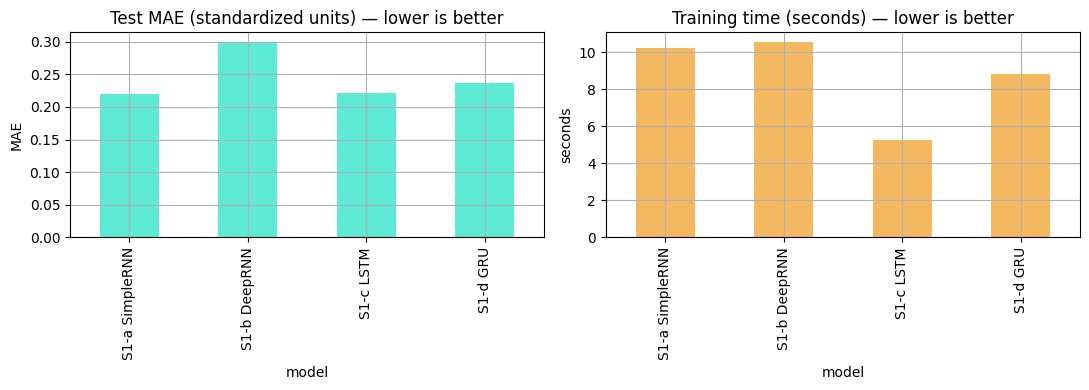

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

results_s1_df["test_mae"].plot(kind="bar", ax=axes[0], grid=True, color="#5eead4")
axes[0].set_title("Test MAE (standardized units) — lower is better")
axes[0].set_ylabel("MAE")

results_s1_df["training_time_sec"].plot(kind="bar", ax=axes[1], grid=True, color="#f4b860")
axes[1].set_title("Training time (seconds) — lower is better")
axes[1].set_ylabel("seconds")

plt.tight_layout()
plt.show()


## 5. Reflection — Scenario 1

*Fill this section in after running the cells above and looking at your actual numbers.
Use the comparison table/plots from Section 4 as evidence for each point.*

**Accuracy — which model generalized best, and why do you think that is?**
- _e.g. did the gated models (LSTM/GRU) clearly beat the plain RNNs, or was the gap small? For a
  short 14-day window and a single smooth feature like temperature, plain RNNs may already do
  fine — long-range memory (LSTM/GRU's main advantage) matters less when the relevant signal is
  entirely within a 14-step window._

- _your observation here_

**Training time — did more parameters / gated units cost noticeably more time?**
- _e.g. LSTM has ~4x the gate parameters of a plain RNN, GRU ~3x — did that show up in wall-clock
  training time in your run, or did the small window/hidden size make the difference negligible?_

- _your observation here_

**Did the deeper RNN help or hurt compared to the simple RNN?**
- _e.g. more layers can add capacity, but also more vanishing/exploding gradient risk and more
  parameters to fit from a fairly small/smooth univariate signal — what did you actually see?_

- _your observation here_

**Overall takeaway for this specific problem (single feature, single-step, 14-day window):**
- _your observation here_
